# CL Spectra Analysis - Linear Scale Visualization

Clean, straightforward plotting of all 30 CL spectra using linear scales:
1. Overview of all spectra together
2. Groups of 10 spectra for detailed analysis

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

# Set matplotlib parameters
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 12

In [37]:
# Load the data
df = pd.read_csv('CL_data.csv', skiprows=[1])  # Skip the units row

# Extract energy and spectra data
energy = pd.to_numeric(df.iloc[:, 0], errors='coerce').values
spectra_data = df.iloc[:, 1:31].apply(pd.to_numeric, errors='coerce').values

# Remove any NaN values
mask = ~np.isnan(energy)
energy = energy[mask]
spectra_data = spectra_data[mask, :]

print(f"Loaded {spectra_data.shape[1]} spectra")
print(f"Energy range: {energy[0]:.3f} - {energy[-1]:.3f} eV")
print(f"Intensity range: {np.min(spectra_data):.2e} - {np.max(spectra_data):.2e}")

Loaded 30 spectra
Energy range: 1.015 - 4.000 eV
Intensity range: 3.04e-30 - 3.85e+03


## Figure 1: All 30 CL Spectra Together (Linear Scale)

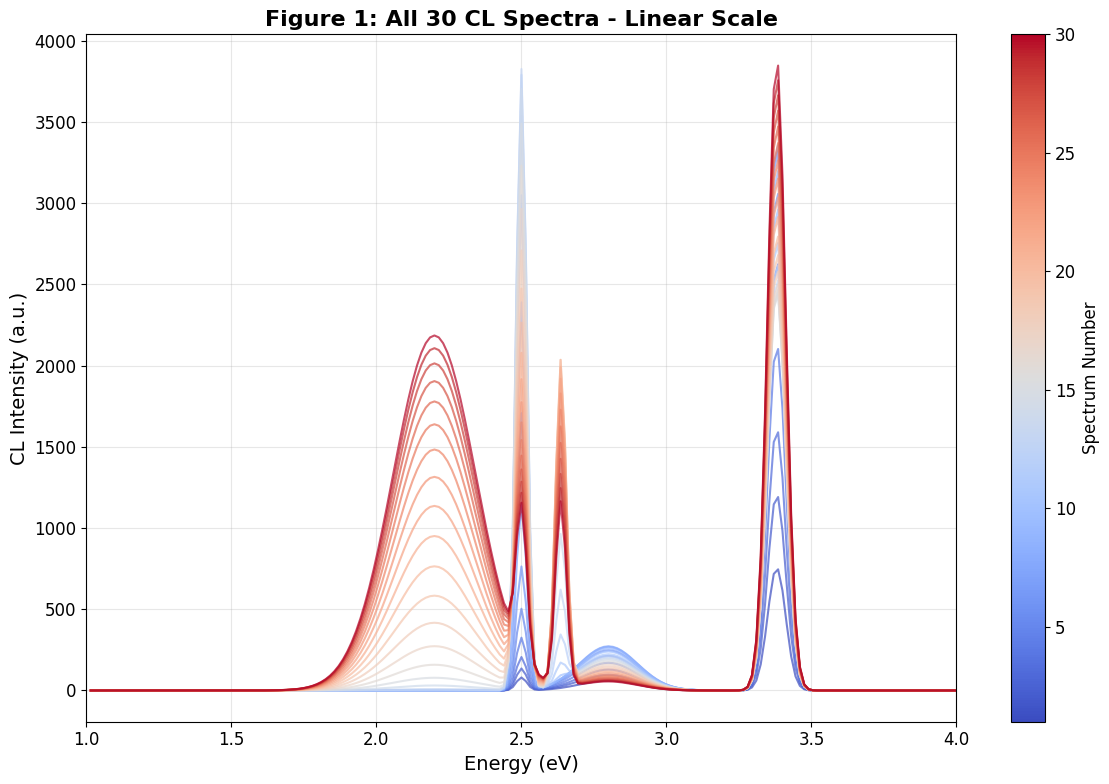

Caption: Overview of all CL spectra showing progression from blue (early) to red (late)


In [38]:
# Plot all 30 spectra together - LINEAR SCALE (Clean & Simple)
fig, ax = plt.subplots(figsize=(12, 8))

# Use a simple, professional color approach - shades of blue to red
colors = cm.coolwarm(np.linspace(0, 1, 30))

for i in range(30):
    ax.plot(energy, spectra_data[:, i], color=colors[i], 
             linewidth=1.5, alpha=0.7)

ax.set_xlabel('Energy (eV)', fontsize=14)
ax.set_ylabel('CL Intensity (a.u.)', fontsize=14)
ax.set_title('Figure 1: All 30 CL Spectra - Linear Scale', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(1.0, 4.0)

# Simple colorbar
sm = cm.ScalarMappable(cmap=cm.coolwarm, norm=Normalize(vmin=1, vmax=30))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Spectrum Number', fontsize=12)

plt.tight_layout()
plt.savefig('Figure1_All_Spectra_Linear.png', dpi=300, bbox_inches='tight')
plt.show()

print("Caption: Overview of all CL spectra showing progression from blue (early) to red (late)")

## Figure 2: Spectra 1-10 (Early/Low Intensity)

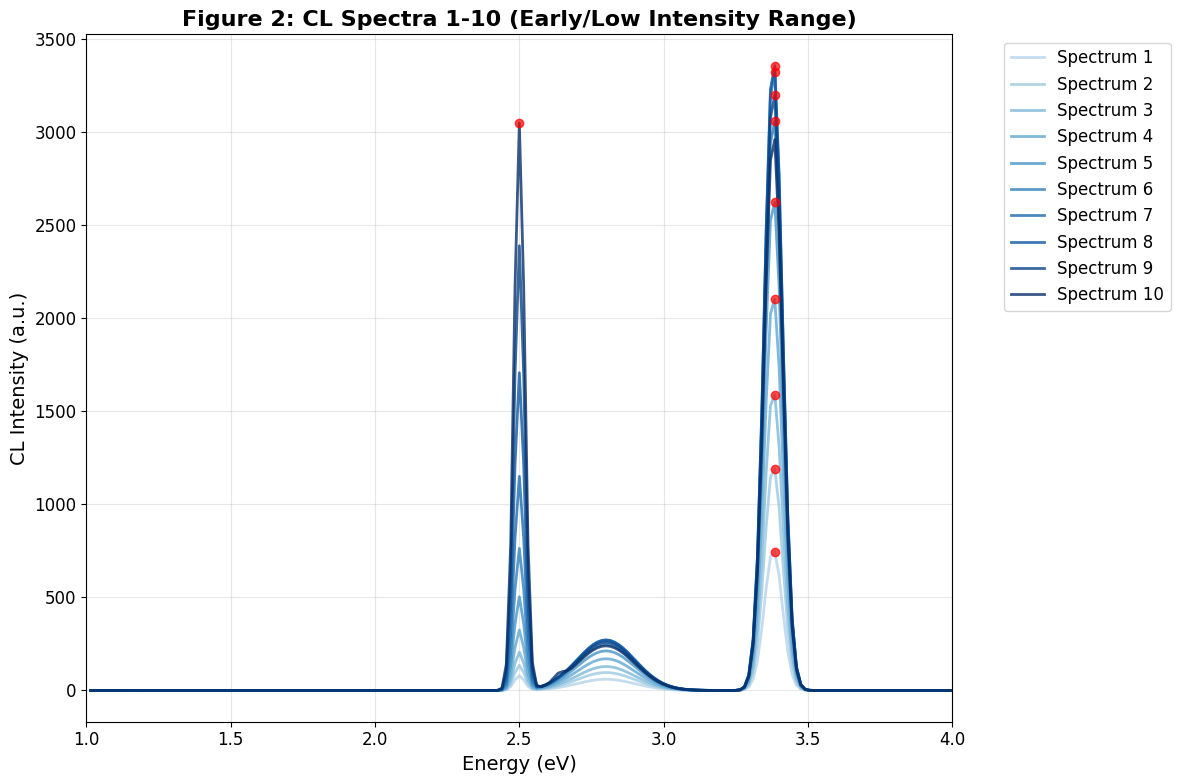

Peak intensities range: 7.46e+02 - 3.36e+03
Red dots show peak positions


In [39]:
# Plot first 10 spectra - LINEAR SCALE
plt.figure(figsize=(12, 8))

colors_group1 = cm.Blues(np.linspace(0.3, 1, 10))

for i in range(10):
    plt.plot(energy, spectra_data[:, i], color=colors_group1[i], 
             linewidth=2, alpha=0.8, label=f'Spectrum {i+1}')

plt.xlabel('Energy (eV)', fontsize=14)
plt.ylabel('CL Intensity (a.u.)', fontsize=14)
plt.title('Figure 2: CL Spectra 1-10 (Early/Low Intensity Range)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1.0, 4.0)

# Find and highlight peaks for this group
for i in range(10):
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energy = energy[peak_idx]
    peak_intensity = spectra_data[peak_idx, i]
    plt.plot(peak_energy, peak_intensity, 'ro', markersize=6, alpha=0.7)

plt.tight_layout()
plt.savefig('Figure2_Spectra_1-10_Linear.png', dpi=300, bbox_inches='tight')
plt.show()

# Show some statistics for this group
group1_peaks = [np.max(spectra_data[:, i]) for i in range(10)]
print(f"Peak intensities range: {min(group1_peaks):.2e} - {max(group1_peaks):.2e}")
print("Red dots show peak positions")

## Figure 3: Spectra 11-20 (Middle/Growing Intensity)

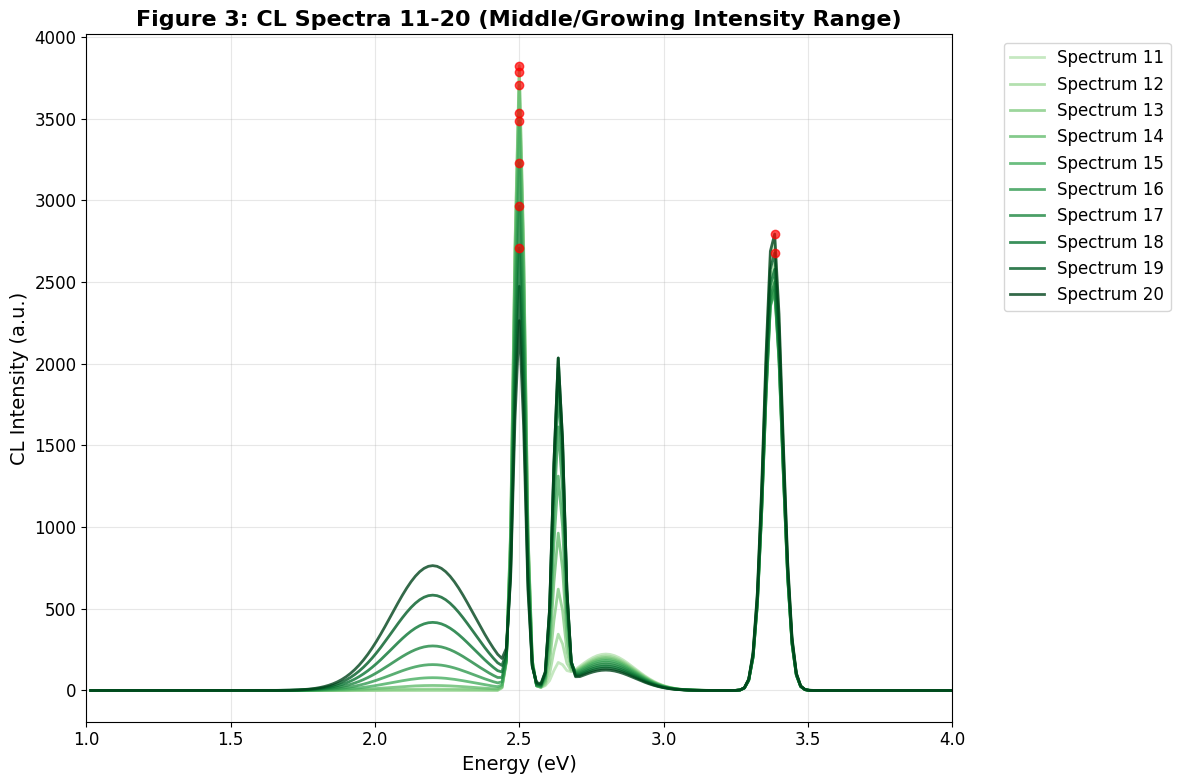

Peak intensities range: 2.68e+03 - 3.83e+03
Red dots show peak positions


In [40]:
# Plot middle 10 spectra - LINEAR SCALE
plt.figure(figsize=(12, 8))

colors_group2 = cm.Greens(np.linspace(0.3, 1, 10))

for i in range(10, 20):
    plt.plot(energy, spectra_data[:, i], color=colors_group2[i-10], 
             linewidth=2, alpha=0.8, label=f'Spectrum {i+1}')

plt.xlabel('Energy (eV)', fontsize=14)
plt.ylabel('CL Intensity (a.u.)', fontsize=14)
plt.title('Figure 3: CL Spectra 11-20 (Middle/Growing Intensity Range)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1.0, 4.0)

# Find and highlight peaks for this group
for i in range(10, 20):
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energy = energy[peak_idx]
    peak_intensity = spectra_data[peak_idx, i]
    plt.plot(peak_energy, peak_intensity, 'ro', markersize=6, alpha=0.7)

plt.tight_layout()
plt.savefig('Figure3_Spectra_11-20_Linear.png', dpi=300, bbox_inches='tight')
plt.show()

# Show some statistics for this group
group2_peaks = [np.max(spectra_data[:, i]) for i in range(10, 20)]
print(f"Peak intensities range: {min(group2_peaks):.2e} - {max(group2_peaks):.2e}")
print("Red dots show peak positions")

## Figure 4: Spectra 21-30 (Late/High Intensity)

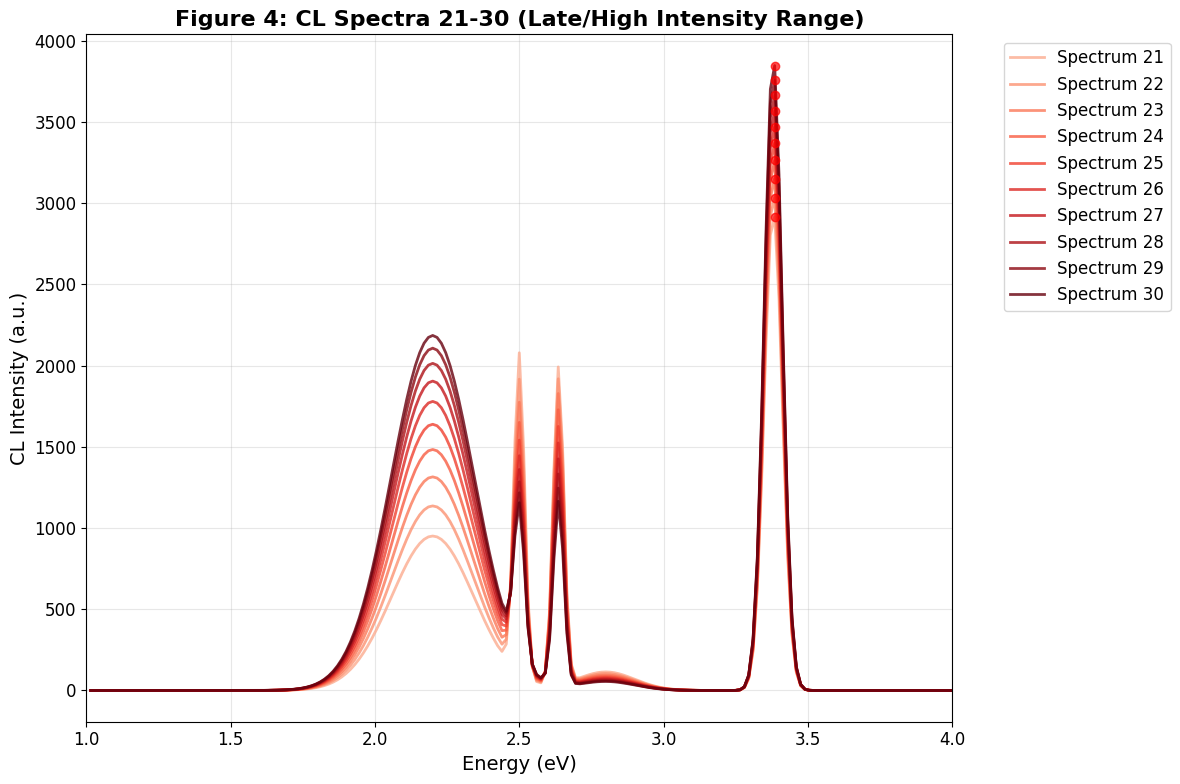

Peak intensities range: 2.91e+03 - 3.85e+03
Red dots show peak positions


In [41]:
# Plot last 10 spectra - LINEAR SCALE
plt.figure(figsize=(12, 8))

colors_group3 = cm.Reds(np.linspace(0.3, 1, 10))

for i in range(20, 30):
    plt.plot(energy, spectra_data[:, i], color=colors_group3[i-20], 
             linewidth=2, alpha=0.8, label=f'Spectrum {i+1}')

plt.xlabel('Energy (eV)', fontsize=14)
plt.ylabel('CL Intensity (a.u.)', fontsize=14)
plt.title('Figure 4: CL Spectra 21-30 (Late/High Intensity Range)', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.xlim(1.0, 4.0)

# Find and highlight peaks for this group
for i in range(20, 30):
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energy = energy[peak_idx]
    peak_intensity = spectra_data[peak_idx, i]
    plt.plot(peak_energy, peak_intensity, 'ro', markersize=6, alpha=0.7)

plt.tight_layout()
plt.savefig('Figure4_Spectra_21-30_Linear.png', dpi=300, bbox_inches='tight')
plt.show()

# Show some statistics for this group
group3_peaks = [np.max(spectra_data[:, i]) for i in range(20, 30)]
print(f"Peak intensities range: {min(group3_peaks):.2e} - {max(group3_peaks):.2e}")
print("Red dots show peak positions")

## Summary: Peak Evolution Analysis

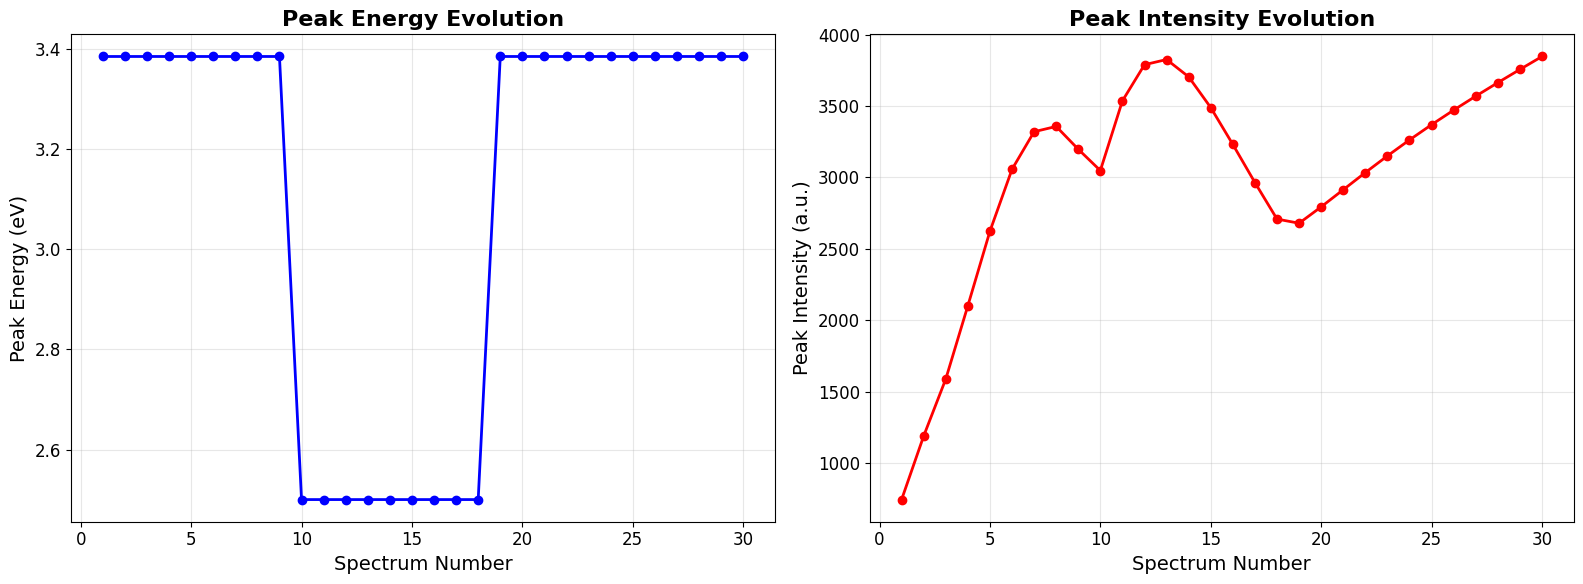


Summary Statistics:
Peak energy range: 2.500 - 3.385 eV
Peak intensity range: 7.46e+02 - 3.85e+03
Intensity increase factor: 5x


In [42]:
# Simple peak analysis across all spectra
peak_energies = []
peak_intensities = []

for i in range(30):
    peak_idx = np.argmax(spectra_data[:, i])
    peak_energies.append(energy[peak_idx])
    peak_intensities.append(spectra_data[peak_idx, i])

# Plot peak evolution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Peak energy evolution
spectrum_numbers = np.arange(1, 31)
ax1.plot(spectrum_numbers, peak_energies, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Spectrum Number', fontsize=14)
ax1.set_ylabel('Peak Energy (eV)', fontsize=14)
ax1.set_title('Peak Energy Evolution', fontsize=16, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Peak intensity evolution
ax2.plot(spectrum_numbers, peak_intensities, 'ro-', linewidth=2, markersize=6)
ax2.set_xlabel('Spectrum Number', fontsize=14)
ax2.set_ylabel('Peak Intensity (a.u.)', fontsize=14)
ax2.set_title('Peak Intensity Evolution', fontsize=16, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Figure5_Peak_Evolution.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nSummary Statistics:")
print(f"Peak energy range: {min(peak_energies):.3f} - {max(peak_energies):.3f} eV")
print(f"Peak intensity range: {min(peak_intensities):.2e} - {max(peak_intensities):.2e}")
print(f"Intensity increase factor: {max(peak_intensities)/min(peak_intensities):.0f}x")